Accuracy: 0.7894736842105263

Confusion Matrix:
[[67  4]
 [20 23]]


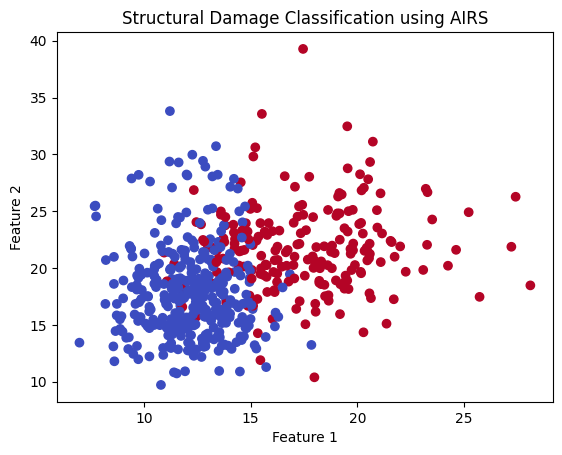

In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load Dataset
# -------------------------------
data = load_breast_cancer()
X = data.data
y = data.target

# Convert labels → 1 = damage, 0 = no damage
y = np.where(y == 0, 1, 0)

# -------------------------------
# 2. Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 3. AIRS Class (Simplified)
# -------------------------------
class AIRS:
    def __init__(self, num_detectors=20, mutation_rate=0.1):
        self.num_detectors = num_detectors
        self.mutation_rate = mutation_rate

    def train(self, X, y):
        # Store labels also
        indices = np.random.choice(len(X), self.num_detectors, replace=False)
        self.detectors = X[indices]
        self.detector_labels = y[indices]

    def predict(self, X):
        predictions = []

        for sample in X:
            # Compute distance to detectors
            distances = np.linalg.norm(self.detectors - sample, axis=1)
            
            # Find closest detector
            nearest_index = np.argmin(distances)
            
            # Assign its label
            prediction = self.detector_labels[nearest_index]
            predictions.append(prediction)

        return np.array(predictions)

# -------------------------------
# 4. Train Model
# -------------------------------
model = AIRS(num_detectors=20, mutation_rate=0.1)
model.train(X_train, y_train)

# -------------------------------
# 5. Predict
# -------------------------------
y_pred = model.predict(X_test)

# -------------------------------
# 6. Evaluate
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# -------------------------------
# 7. Visualization (2D view)
# -------------------------------
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.title("Structural Damage Classification using AIRS")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()